# Exploracion inicial

Diagnostico reproducible de la muestra NVD 2025-Q1 integrada con el feed CISA KEV.
`in_kev = 0` significa no encontrada en el catalogo descargado, no "no explotada".

In [1]:
from pathlib import Path
import os
import pandas as pd

root = Path.cwd()
if not (root / "README.md").exists():
    root = root.parent
(root / ".matplotlib").mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(root / ".matplotlib"))
import matplotlib.pyplot as plt
processed = root / "data" / "processed" / "vulnerabilities_2025_q1.csv"
sample = root / "data" / "sample" / "analytical_sample_2025_q1.csv"
data_path = processed if processed.exists() else sample
df = pd.read_csv(data_path)
for column in ["published", "last_modified", "date_added", "due_date"]:
    df[column] = pd.to_datetime(df[column], errors="coerce", utc=True)
print(f"Dataset: {data_path.relative_to(root)}")
print("Los resultados corresponden al archivo indicado arriba.")

Dataset: data\processed\vulnerabilities_2025_q1.csv
Los resultados corresponden al archivo indicado arriba.


## Primeras filas

In [2]:
display(df.head())

,cve_id,published,last_modified,vuln_status,cwe_id,nvd_extracted_at_utc,cvss_version,cvss_source,base_score,severity,...,vulnerability_name,date_added,short_description,required_action,due_date,known_ransomware_campaign_use,notes,kev_extracted_at_utc,in_kev,days_to_kev
0,CVE-2024-21675,2025-01-01 00:15:07.193000+00:00,2025-01-01 00:15:07.193000+00:00,Rejected,NaN,2026-09-10T23:40:04.178604Z,NaN,NaN,NaN,NaN,...,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,0,NaN
1,CVE-2024-21679,2025-01-01 00:15:07.267000+00:00,2025-01-01 00:15:07.267000+00:00,Rejected,NaN,2026-09-10T23:40:04.178604Z,NaN,NaN,NaN,NaN,...,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,0,NaN
2,CVE-2024-21688,2025-01-01 00:15:36.373000+00:00,2025-01-01 00:15:36.373000+00:00,Rejected,NaN,2026-09-10T23:40:04.178604Z,NaN,NaN,NaN,NaN,...,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,0,NaN
3,CVE-2024-21691,2025-01-01 00:15:36.447000+00:00,2025-01-01 00:15:36.447000+00:00,Rejected,NaN,2026-09-10T23:40:04.178604Z,NaN,NaN,NaN,NaN,...,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,0,NaN
4,CVE-2024-21692,2025-01-01 00:15:36.510000+00:00,2025-01-01 00:15:36.510000+00:00,Rejected,NaN,2026-09-10T23:40:04.178604Z,NaN,NaN,NaN,NaN,...,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,0,NaN


## Dimensiones y tipos

In [3]:
print(f'Filas: {df.shape[0]:,}; columnas: {df.shape[1]}')
display(df.dtypes.rename('tipo').to_frame())

Filas: 12,412; columnas: 29


,tipo
cve_id,object
published,"datetime64[ns, UTC]"
last_modified,"datetime64[ns, UTC]"
vuln_status,object
cwe_id,object
nvd_extracted_at_utc,object
cvss_version,float64
cvss_source,object
base_score,float64
severity,object


## Valores faltantes

In [4]:
missing = pd.DataFrame({'faltantes': df.isna().sum(), 'porcentaje': (df.isna().mean()*100).round(2)})
display(missing.sort_values('porcentaje', ascending=False))

,faltantes,porcentaje
days_to_kev,12370,99.66
vulnerability_name,12354,99.53
kev_extracted_at_utc,12354,99.53
notes,12354,99.53
required_action,12354,99.53
vendor_project,12354,99.53
short_description,12354,99.53
due_date,12354,99.53
known_ransomware_campaign_use,12354,99.53
date_added,12354,99.53


## Duplicados y CVE unicas

In [5]:
print('Filas duplicadas:', int(df.duplicated().sum()))
print('cve_id duplicadas:', int(df.duplicated('cve_id').sum()))
print('CVE unicas:', int(df['cve_id'].nunique()))

Filas duplicadas: 0
cve_id duplicadas: 0
CVE unicas: 12412


## Estadisticas descriptivas

In [6]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
cve_id,12412,12412,CVE-2024-21675,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
published,12374,NaN,NaN,NaN,2025-02-15 14:41:13.502371072+00:00,2025-01-01 00:15:07.193000+00:00,2025-01-21 23:15:11.463500032+00:00,2025-02-17 01:45:09.866500096+00:00,2025-03-10 15:15:37.234249984+00:00,2025-03-31 23:15:30.630000+00:00,NaN
last_modified,12356,NaN,NaN,NaN,2026-06-01 16:57:10.928555776+00:00,2025-01-01 00:15:07.193000+00:00,2026-06-17 07:17:13.235750144+00:00,2026-06-17 08:38:30.436499968+00:00,2026-06-17 08:59:48.518249984+00:00,2026-09-08 16:17:47.957000+00:00,NaN
vuln_status,12412,5,Analyzed,5576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cwe_id,11409,365,CWE-79,2527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nvd_extracted_at_utc,12412,1,2026-09-10T23:40:04.178604Z,12412,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cvss_version,11946.0,NaN,NaN,NaN,3.236272,3.0,3.1,3.1,3.1,4.0,0.326245
cvss_source,11946,187,nvd@nist.gov,3233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
base_score,11946.0,NaN,NaN,NaN,6.610054,1.0,5.4,6.5,7.5,10.0,1.599212
severity,11946,4,MEDIUM,6547,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Distribuciones


severity


,conteo
severity,
MEDIUM,6547
HIGH,4070
CRITICAL,1025
MISSING,466
LOW,304



attack_vector


,conteo
attack_vector,
NETWORK,8745
LOCAL,2774
MISSING,466
ADJACENT_NETWORK,196
PHYSICAL,134
ADJACENT,97



in_kev


,conteo
in_kev,
0,12354
1,58


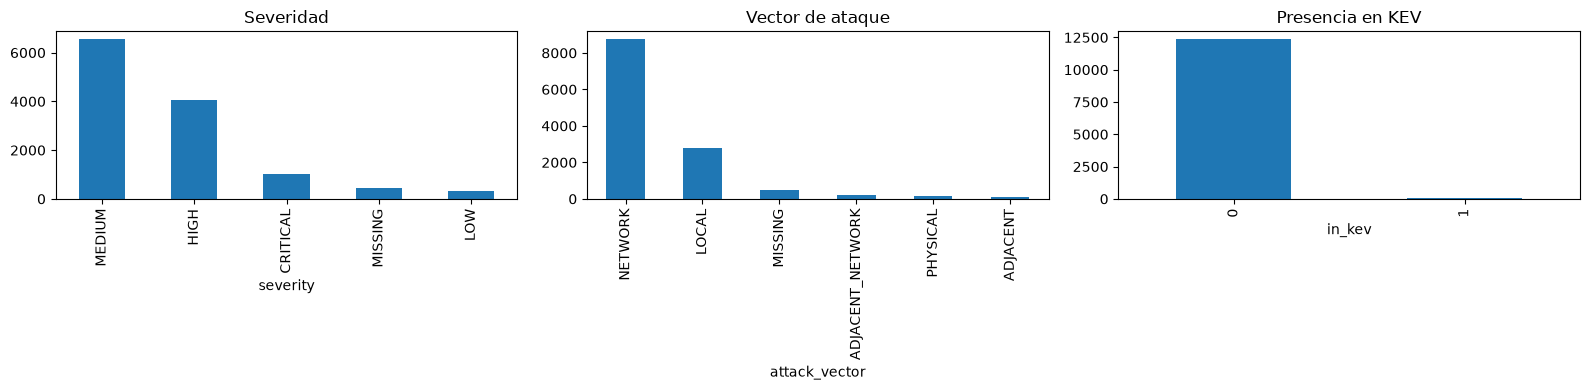

In [7]:
for column in ["severity", "attack_vector", "in_kev"]:
    print(f"\n{column}")
    display(df[column].fillna("MISSING").value_counts(dropna=False).rename("conteo").to_frame())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df["severity"].fillna("MISSING").value_counts().plot.bar(ax=axes[0], title="Severidad")
df["attack_vector"].fillna("MISSING").value_counts().plot.bar(ax=axes[1], title="Vector de ataque")
df["in_kev"].value_counts().sort_index().plot.bar(ax=axes[2], title="Presencia en KEV")
plt.tight_layout()
plt.show()

## Rango de fechas

In [8]:
print("Publicacion minima:", df["published"].min())
print("Publicacion maxima:", df["published"].max())
print("Ultima modificacion maxima:", df["last_modified"].max())

Publicacion minima: 2025-01-01 00:15:07.193000+00:00
Publicacion maxima: 2025-03-31 23:15:30.630000+00:00
Ultima modificacion maxima: 2026-09-08 16:17:47.957000+00:00


## Inconsistencias y problemas de calidad

In [9]:
quality = {
    "cve_id con formato invalido": int((~df["cve_id"].str.match(r"^CVE-\d{4}-\d{4,}$", na=False)).sum()),
    "filas duplicadas": int(df.duplicated().sum()),
    "cve_id duplicadas": int(df.duplicated("cve_id").sum()),
    "days_to_kev negativos": int((df["days_to_kev"].dropna() < 0).sum()),
}
display(pd.Series(quality, name="conteo").to_frame())

,conteo
cve_id con formato invalido,0
filas duplicadas,0
cve_id duplicadas,0
days_to_kev negativos,0


## Observaciones iniciales y trabajo futuro

In [10]:
print(f"CVE presentes en KEV: {int(df['in_kev'].sum()):,} de {len(df):,} ({df['in_kev'].mean()*100:.4f}%).")
print("La ausencia en KEV no significa que el resto no haya sido explotado.")
print("Transformaciones futuras: procesamiento por lotes, Parquet particionado y validaciones ampliadas.")
print("Preguntas abiertas: estabilidad temporal, diferencias entre versiones CVSS y cobertura de CWE.")

CVE presentes en KEV: 58 de 12,412 (0.4673%).
La ausencia en KEV no significa que el resto no haya sido explotado.
Transformaciones futuras: procesamiento por lotes, Parquet particionado y validaciones ampliadas.
Preguntas abiertas: estabilidad temporal, diferencias entre versiones CVSS y cobertura de CWE.
